# Дизайн кода и архитектура: domain driven design, чистая архитектура

## Цели занятия
- познакомиться с принципами и терминологией DDD
- изучить Clean Architecture как подход и его применимость в Python-проектах

## Краткое содержание
- ubiquitous language
- domain services
- value objects
- entity
- aggregate
- repository
- Стратегические понятия DDD
- принципы чистой архитектуры и границы применимости

### Что такое DDD

Domain-Driven Design это подход, в центре которого не фреймворк, а бизнес-смысл. Он предлагает строить архитектуру вокруг модели предметной области, а не вокруг базы данных, API или "как проще сделать сейчас".

DDD дает разработчику не набор паттернов, а способ думать о системе так, чтобы код отражал предметную область.

## Задача

Разработать приложение для ресторана с примерением DDD и чистой архитектуры.

## Сущности DDD

### Ubiquitous Language (Единый язык)

Общий словарь терминов между разработчиками, аналитиками, продуктом и предметными экспертами.
Каждое слово — с чётким и единым смыслом внутри конкретного bounded context.

Зачем нужен
- устраняет ложные трактовки
- делает код отражением бизнес-логики
- облегчает общение между ролями
- позволяет обсуждать систему без перевода между “бизнесом” и “программистами”

#### Пример (ресторан)
Если в домене принято говорить «бронь», но в коде у вас Order, а в документации «reservation ticket» — вы живёте в трёх мирах одновременно.
UL заставляет выбрать один термин: Reservation, и использовать его везде.

### Entity
Объект домена с устойчивой идентичностью, жизненным циклом и изменяемым состоянием.

Зачем нужен
- моделирует ключевые бизнес-объекты, которые живут во времени
- несёт состояние и поведение
- обеспечивает выполнение бизнес-инвариантов

#### Пример (ресторан)
Reservation
- имеет идентификатор
- меняет статус, время, гостей
- переходит по жизненному пути
- может быть отменено, подтверждено, завершено

### Domain Service
Объект/функция доменной логики, которая не принадлежит ни одной сущности, но относится к предметной области.

Зачем нужен:
- чтобы не раздувать сущности логикой, не относящейся к ним напрямую
- чтобы выразить процессы, где участвуют несколько сущностей
- чтобы держать доменную модель чистой и последовательной

#### Пример (ресторан)
TableAllocationService — выбирает подходящий стол:
учитывает вместимость, время, доступность, предпочтения.
Этот алгоритм не принадлежит ни Table, ни Reservation, но принадлежит домену.

### Value Object (VO)
Объект, ценность которого определяется только значением, а не идентичностью.
Обычно неизменяемый.

Зачем нужен
инкапсулирует правила в единицах смысла
делает модель выразительной
уменьшает вероятность ошибок
избавляет от хрупких «сырых» типов (строк, цифр)

#### Примеры (ресторан)
- TimeSlot(start, end)
- PartySize(n)
- PhoneNumber(value)
- Money(amount, currency)

VO проверяют корректность сами по себе:
нельзя создать TimeSlot с end < start; нельзя иметь PartySize = 0.

### Aggregate
Группа сущностей и VO, образующая единый блок логики с инвариантами (__Бизнес-правила и ограничения, которые всегда должны быть истинны для объектов предметной области, обеспечивая их консистентность и корректность состояния. Они гарантируют, что данные внутри агрегата (группы объектов) или между разными доменами остаются в допустимом состоянии, например: "цена не может быть отрицательной" или "нельзя заказать больше товара, чем есть в наличии"__).
У агрегата всегда есть Root — главный объект.

Зачем нужен
- обеспечивает корректность данных
- предотвращает нарушение бизнес-правил
- ограничивает доступ извне только через root
- уменьшает связанность между частями домена

#### Пример (ресторан)
Агрегат Reservation

Внутри:
- Reservation entity
- TimeSlot (VO)
- PartySize (VO)
- TableId (VO)

Инварианты:
- нельзя бронировать стол, если он уже занят
- PartySize не может превышать вместимость стола
- статус меняется по строгому пути

### Repository
Абстракция доступа к агрегату.
Контракт, который говорит: как загрузить агрегат, как его сохранить.
Домен ничего не знает о базе данных.

Зачем нужен
- отделяет домен от инфраструктуры
-позволяет тестировать доменную модель без БД
-инкапсулирует детали хранилища
- обеспечивает работу с агрегатами как с целым объектом

#### Пример (ресторан)
ReservationRepository
- get(id)
- add(reservation)
- find_for_timeslot(slot)

Внутри может быть SQLAlchemy, raw SQL, Mongo — домену всё равно.

### Примеры

#### 1. Entity

```python
class Reservation:
    def __init__(self, reservation_id, time_slot, party_size, table_id, status="CREATED"):
        self.id = reservation_id
        self.time_slot = time_slot
        self.party_size = party_size
        self.table_id = table_id
        self.status = status

    def confirm(self):
        if self.status != "CREATED":
            raise ValueError("Only new reservations can be confirmed")
        self.status = "CONFIRMED"

    def cancel(self):
        if self.status in ("CANCELLED", "COMPLETED"):
            raise ValueError("Reservation already closed")
        self.status = "CANCELLED"
```

#### 2. Value Object (VO)

```python
from dataclasses import dataclass

@dataclass(frozen=True)
class TimeSlot:
    start: str
    end: str

    def validate(self):
        if self.start >= self.end:
            raise ValueError("Invalid time slot")
```

#### 3. Aggregate
Определение

Группа сущностей и VO, образующая единицу консистентности.
Все инварианты соблюдаются внутри агрегата.

Зачем нужен
- локализует бизнес-правила
- защищает модель от неправильных изменений
- уменьшает связанность
- задаёт чёткие границы для транзакций

Пример

Агрегат Reservation включает:
- Reservation (Entity) — root
- TimeSlot (VO)
- PartySize (VO)
- TableId (VO)

Вызывающий код не может менять TimeSlot напрямую — только через root.

#### 4. Aggregate Root
Главная сущность агрегата. Единственная точка взаимодействия агрегата с внешним миром.

Зачем нужен
- контролирует целостность агрегата
- гарантирует выполнение инвариантов
- ограничивает внешние изменения

Пример
```python
class Reservation:  # root
    def change_time(self, new_slot: TimeSlot):
        new_slot.validate()
        self.time_slot = new_slot
```

А вот так нельзя:
```python
reservation.time_slot.start = "21:00"
```

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from enum import Enum
from typing import List, Optional, Any

from .events import (
    ReservationCreated,
    ReservationConfirmed,
    ReservationCancelled,
    TableAssigned,
)


# -----------------------------
# Value Objects (VO)
# -----------------------------

@dataclass(frozen=True)
class TimeSlot:
    start: datetime
    end: datetime

    def __post_init__(self) -> None:
        # Invariant: start < end
        if self.start >= self.end:
            raise ValueError("TimeSlot invariant violated: start must be < end")


@dataclass(frozen=True)
class PartySize:
    value: int

    def __post_init__(self) -> None:
        # Invariant: party size >= 1
        if self.value < 1:
            raise ValueError("PartySize invariant violated: must be >= 1")


@dataclass(frozen=True)
class TableId:
    value: str


class ReservationStatus(str, Enum):
    CREATED = "CREATED"
    CONFIRMED = "CONFIRMED"
    CANCELLED = "CANCELLED"
    COMPLETED = "COMPLETED"


# -----------------------------
# Aggregate Root
# -----------------------------
class User:
    pass
    
class Reservation:
    """
    Reservation = Aggregate Root (в нашем bounded context Booking).

    Важное:
    - Инварианты проверяются и защищаются здесь (в root-методах).
    - Внешний мир должен изменять агрегат только через методы Reservation.
    - События пишем в self.events, а application layer уже решит как их обрабатывать.
    """

    def __init__(
        self,
        user: User,
        slot: TimeSlot,
        party_size: PartySize,
        table_id: Optional[TableId] = None,
    ) -> None:
        self.id = reservation_id
        self.user = user
        self.slot = slot
        self.party_size = party_size
        self.table_id = table_id
        self.status = ReservationStatus.CREATED

        # Domain events (outbox внутри агрегата)
        self.events: List[Any] = [ReservationCreated(self.id, datetime.utcnow())]

    def assign_table(self, table_id: TableId) -> None:
        # Invariant: assignment allowed only when CREATED
        if self.status != ReservationStatus.CREATED:
            raise ValueError("Invariant: can assign table only for CREATED reservation")
        self.table_id = table_id
        self.events.append(TableAssigned(self.id, table_id.value, datetime.utcnow()))

    def change_reservation_time(new_slot: TimeSlot):
        pass

    def confirm(self) -> None:
        # Invariant: confirm only from CREATED
        if self.status != ReservationStatus.CREATED:
            raise ValueError("Invariant: only CREATED reservation can be confirmed")
        # Invariant: cannot confirm without table
        if self.table_id is None:
            raise ValueError("Invariant: cannot confirm without assigned table")

        self.status = ReservationStatus.CONFIRMED
        self.events.append(ReservationConfirmed(self.id, datetime.utcnow()))

    def cancel(self) -> None:
        # Invariant: cannot cancel completed
        if self.status == ReservationStatus.COMPLETED:
            raise ValueError("Invariant: cannot cancel COMPLETED reservation")
        if self.status == ReservationStatus.CANCELLED:
            return

        self.status = ReservationStatus.CANCELLED
        self.events.append(ReservationCancelled(self.id, datetime.utcnow()))

    def mark_completed(self) -> None:
        if self.status != ReservationStatus.CONFIRMED:
            raise ValueError("Invariant: can complete only CONFIRMED reservation")
        self.status = ReservationStatus.COMPLETED

#### 5. Domain Service
Функция предметной области, которая не принадлежит ни одной сущности, но относится к бизнес-логике.

Зачем нужен
- выносит операцию, связанную с несколькими сущностями
- предотвращает раздувание Entity
- делает модель чище и структурнее

Пример
```python
class TableAllocationService:
    def allocate(self, tables, reservation):
        suitable = [
            t for t in tables 
            if t.capacity >= reservation.party_size
            and t.is_available(reservation.time_slot)
        ]
        if not suitable:
            raise ValueError("No available table")
        return min(suitable, key=lambda t: t.capacity)
```

#### 6. Domain Event

Факт, который произошёл в домене и может вызвать реакции.

Зачем нужен
- связывает bounded contexts
- уменьшает связанность
- фиксирует историю
- позволяет реагировать на изменения

Пример
```python
@dataclass
class ReservationCreated:
    reservation_id: str
    time_slot: TimeSlot
    party_size: int


# И эмит события из root:

class Reservation:
    def __init__(...):
        ...
        self.events = [ReservationCreated(self.id, self.time_slot, self.party_size)]
```

#### 7. Repository
Абстракция хранилища, обеспечивающая загрузку и сохранение агрегатов.

Зачем нужен
- отделяет домен от инфраструктуры
- позволяет тестировать домен без БД
- скрывает SQL/ORM/внешние API
- даёт доменной модели чистый контракт

Пример
```python
class ReservationRepository:
    def get(self, reservation_id) -> Reservation:
        raise NotImplementedError

    def add(self, reservation: Reservation):
        raise NotImplementedError
```

Реализация (SQLAlchemy, например):

```python
class SqlAlchemyReservationRepository(ReservationRepository):
    def __init__(self, session):
        self.session = session

    def get(self, reservation_id):
        return self.session.query(ReservationModel).get(reservation_id).to_domain()

    def add(self, reservation):
        self.session.add(ReservationModel.from_domain(reservation))
```

#### 8. Factory
Объект/функция, создающая сложные агрегаты, скрывая детали.

Зачем нужен
- обеспечивает корректность создания моделей
- избавляет от громоздких конструкторов
-инкапсулирует процедуру инициализации

Пример
```python
import uuid

class ReservationFactory:
    def create(self, time_slot, party_size, table_id):
        reservation_id = str(uuid.uuid4())
        reservation = Reservation(
            reservation_id=reservation_id,
            time_slot=time_slot,
            party_size=party_size,
            table_id=table_id,
        )
        reservation.events.append(ReservationCreated(reservation_id, time_slot, party_size))
        return reservation
```

### Стратегические понятия DDD

### Bounded Context (Ограниченный контекст)

Чётко очерченная граница, внутри которой термины и модель имеют однозначный смысл.

Зачем:
- Один и тот же термин может означать разное в разных частях системы — и это нормально, если контексты разделены.

Пример:
- В Booking Context Reservation — это бронь стола
- В Billing Context Reservation — это финансовое обязательство
- В Kitchen Context такого понятия может не быть вовсе

Bounded Context — это не модуль и не микросервис, а граница смысла.

### Subdomain (Поддомен)

Что это:
- Часть бизнес-домена с отдельной целью и ценностью.

DDD делит поддомены на три типа:

#### 1. Core Domain (Ядро)

Что это:
- Самая ценная часть бизнеса. То, что даёт конкурентное преимущество.

Зачем:
- требует максимального внимания
- пишется своей командой
- сложная, богатая модель

Пример:
- Алгоритмы распределения столов + правила посадки VIP-гостей.

####  2. Supporting Subdomain (Поддерживающий поддомен)

Что это:
- Нужен бизнесу, но не является конкурентным преимуществом.

Зачем:
- поддерживает Core
- можно писать проще
- иногда допустим CRUD

Пример:
- Управление персоналом, расписания смен, отчёты.

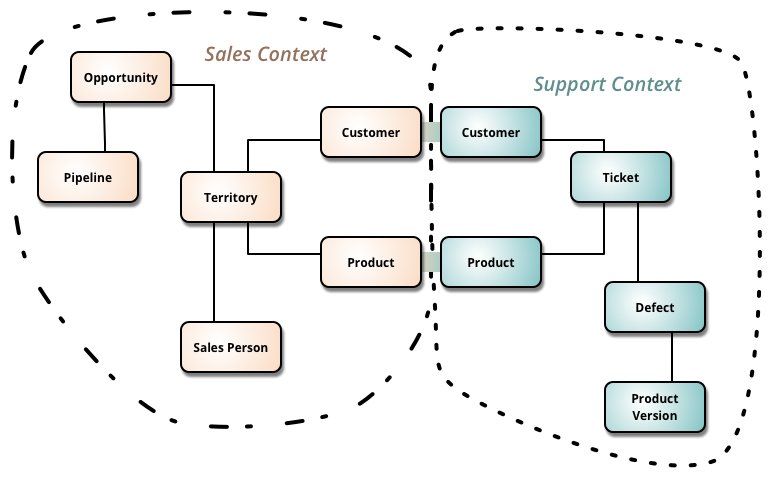

#### 3. Generic Subdomain (Общий / типовой)

Что это:
- Область, которая одинакова почти у всех.

Зачем:
- не тратить силы
- брать готовые решения

Пример:
- Аутентификация, логирование, email-рассылки.

#### Context Map (Карта контекстов)

Что это:
- Диаграмма, показывающая:

- какие bounded contexts существуют
- как они взаимодействуют
- кто от кого зависит

Зачем:
- Чтобы не превратить систему в кашу интеграций.

#### Типы взаимодействия между контекстами
##### 1. Partnership

Обе команды тесно координируются.

##### 2. Customer / Supplier

Один контекст — поставщик модели, другой — потребитель.

##### 3. Conformist

Контекст полностью подстраивается под чужую модель (часто плохо, но иногда нужно).

##### 4. Anti-Corruption Layer (ACL)

Что это:
- Адаптер, который защищает вашу модель от чужой.

Пример:
- Внешняя CRM присылает странные DTO → ACL переводит их в вашу доменную модель.

##### Shared Kernel

Что это:
- Небольшая часть модели, разделяемая между несколькими контекстами.

Зачем:
- Чтобы не дублировать базовые вещи.

Опасность:
- Жёсткая связность - требует дисциплины.

##### Open Host Service

Что это:
- Контекст публикует стабильный API/события для других.

Пример:
- Booking Context публикует события ReservationCreated, ReservationCancelled.

##### Published Language

Что это:
- Формальный язык интеграции (DTO, схемы, события), отличающийся от внутренней модели.

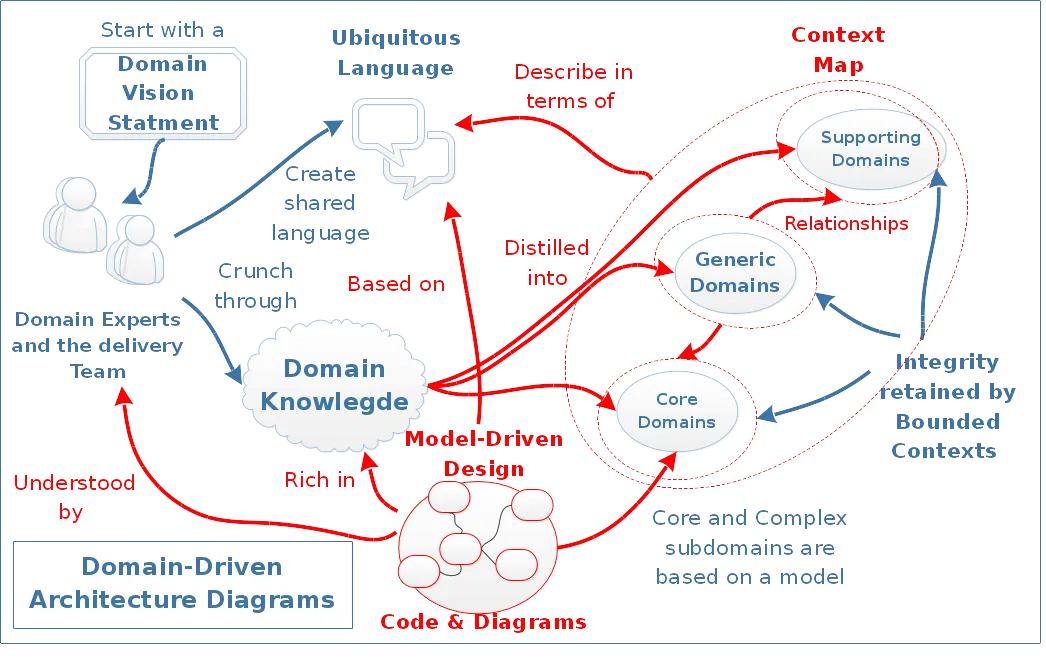

## Проект

### Layout

In [ ]:
restaurant/
  booking/                        # Bounded Context: Booking
    domain/                       # ДОМЕННЫЙ СЛОЙ (не знает про БД/HTTP)
      model.py                    # Entity/ValueObject/AggregateRoot + инварианты
      services.py                 # Domain Service
      events.py                   # Domain Events
      repository.py               # Repository интерфейсы (порты)
    application/                  # ПРИЛОЖЕНИЕ (use cases, orchestration)
      commands.py                 # DTO команд (входные данные сценариев)
      handlers.py                 # Application services / use-case handlers
      unit_of_work.py             # UoW интерфейс (порт)
      messagebus.py               # диспетчер событий/команд (опционально)
    infrastructure/               # ИНФРАСТРУКТУРА (адаптеры)
      persistence.py              # SQLAlchemy models, mappers (если нужно)
      repositories.py             # реализации репозиториев (адаптеры)
      uow.py                      # реализация Unit of Work
    entrypoints/                  # ВНЕШНИЕ АДАПТЕРЫ (API/CLI)
      fastapi_app.py              # HTTP контроллеры, валидация входа, вызов use cases

  seating/ ...                    # другие bounded contexts (контуром)
  kitchen/ ...
  billing/ ...
  crm/ ...

### Domain

In [ ]:
# booking/domain/events.py

from dataclasses import dataclass
from datetime import datetime


# Domain Event = факт, который произошёл в домене
@dataclass(frozen=True)
class ReservationCreated:
    reservation_id: str
    occurred_at: datetime


@dataclass(frozen=True)
class ReservationConfirmed:
    reservation_id: str
    occurred_at: datetime


@dataclass(frozen=True)
class ReservationCancelled:
    reservation_id: str
    occurred_at: datetime

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from enum import Enum
from typing import Any, List, Optional

from .events import (
    ReservationCreated,
    ReservationConfirmed,
    ReservationCancelled,
    TableAssigned,
)

# =============================================================================
# VALUE OBJECTS (VO)
# =============================================================================

@dataclass(frozen=True)
class TimeSlot:
    start: datetime
    end: datetime

    def __post_init__(self) -> None:
        if self.start >= self.end:
            raise ValueError("TimeSlot invariant: start must be < end")


@dataclass(frozen=True)
class PartySize:
    value: int

    def __post_init__(self) -> None:
        if self.value < 1:
            raise ValueError("PartySize invariant: must be >= 1")


@dataclass(frozen=True)
class TableId:
    value: str


class ReservationStatus(str, Enum):
    CREATED = "CREATED"
    CONFIRMED = "CONFIRMED"
    CANCELLED = "CANCELLED"
    COMPLETED = "COMPLETED"


# =============================================================================
# ENTITY
# =============================================================================
# Entity = идентичность + изменяемое состояние.
# =============================================================================

class Reservation:
    """
    Entity:
    - имеет устойчивую идентичность: id
    - содержит состояние: slot, party_size, table_id, status
    - сама по себе НЕ является границей согласованности.
      Граница (Aggregate) будет отдельным объектом.
    """

    def __init__(
        self,
        reservation_id: str,
        slot: TimeSlot,
        party_size: PartySize,
        table_id: Optional[TableId] = None,
        status: ReservationStatus = ReservationStatus.CREATED,
    ) -> None:
        self.id = reservation_id
        self.slot = slot
        self.party_size = party_size
        self.table_id = table_id
        self.status = status


# =============================================================================
# AGGREGATE
# =============================================================================
# Aggregate = граница согласованности + инварианты + события.
#
# Aggregate Root = root-Entity, через которую внешний мир взаимодействует
# с агрегатом. Здесь root = Reservation entity.
#
# Чтобы "агрегат менялся через root", мы:
# - прячем изменения Entity за методами Aggregate
# - даём наружу root только для чтения (property root)
# =============================================================================

class ReservationAggregate:
    """
    Aggregate (граница):
    - содержит root-entity Reservation
    - защищает инварианты (правила, которые должны быть истинны всегда)
    - накапливает Domain Events в self.events

    Внешний код вызывает методы агрегата, а агрегат меняет root.
    """

    def __init__(self, root: Reservation) -> None:
        self._root = root
        self.events: List[Any] = []

    # ---------- Root доступен наружу только для чтения ----------
    @property
    def root(self) -> Reservation:
        return self._root

    # ---------- Factory-like constructor (удобно) ----------
    @classmethod
    def create(cls, reservation_id: str, slot: TimeSlot, party_size: PartySize) -> "ReservationAggregate":
        root = Reservation(reservation_id=reservation_id, slot=slot, party_size=party_size)
        agg = cls(root)
        agg.events.append(ReservationCreated(root.id, datetime.utcnow()))
        return agg

    # ---------- Operations (изменяют root и защищают инварианты) ----------

    def assign_table(self, table_id: TableId) -> None:
        # Invariant: assignment only when CREATED
        if self._root.status != ReservationStatus.CREATED:
            raise ValueError("Invariant: can assign table only for CREATED reservation")

        self._root.table_id = table_id
        self.events.append(TableAssigned(self._root.id, table_id.value, datetime.utcnow()))

    def confirm(self) -> None:
        # Invariant: confirm only from CREATED
        if self._root.status != ReservationStatus.CREATED:
            raise ValueError("Invariant: only CREATED reservation can be confirmed")

        # Invariant: cannot confirm without table
        if self._root.table_id is None:
            raise ValueError("Invariant: cannot confirm without assigned table")

        self._root.status = ReservationStatus.CONFIRMED
        self.events.append(ReservationConfirmed(self._root.id, datetime.utcnow()))

    def cancel(self) -> None:
        # Invariant: cannot cancel COMPLETED
        if self._root.status == ReservationStatus.COMPLETED:
            raise ValueError("Invariant: cannot cancel COMPLETED reservation")

        # idempotent
        if self._root.status == ReservationStatus.CANCELLED:
            return

        self._root.status = ReservationStatus.CANCELLED
        self.events.append(ReservationCancelled(self._root.id, datetime.utcnow()))

    def mark_completed(self) -> None:
        # Invariant: can complete only CONFIRMED
        if self._root.status != ReservationStatus.CONFIRMED:
            raise ValueError("Invariant: can complete only CONFIRMED reservation")

        self._root.status = ReservationStatus.COMPLETED

In [ ]:
# booking/domain/services.py

from typing import Iterable

from .model import Reservation, TableId


# Domain Service = доменная логика, не принадлежащая одной Entity.
# Здесь — выбор стола. Важно: это всё ещё домен, без БД/HTTP.
class TableAllocationService:
    def allocate(self, reservation: Reservation, available_tables: Iterable[dict]) -> TableId:
        """
        available_tables: iterable of dicts like {"id": "T1", "capacity": 4}
        В реальном мире это могут быть Entities другого контекста (Seating),
        но внутри Booking мы работаем со своей моделью/представлением.
        """
        # Инвариант/правило: стол должен вмещать всех гостей
        suitable = [t for t in available_tables if t["capacity"] >= reservation.party_size.value]
        if not suitable:
            raise ValueError("No suitable table available")

        # Простая стратегия: самый маленький подходящий
        chosen = min(suitable, key=lambda t: t["capacity"])
        return TableId(chosen["id"])


In [ ]:
# booking/domain/repository.py

from typing import Protocol, Optional, List

from .model import Reservation, TimeSlot


# Repository = абстракция доступа к агрегату (порт)
class ReservationRepository(Protocol):
    def get(self, reservation_id: str) -> Optional[Reservation]: ...
    def add(self, reservation: Reservation) -> None: ...
    def list_for_slot(self, slot: TimeSlot) -> List[Reservation]: ...

In [ ]:
# booking/domain/factory.py

import uuid
from datetime import datetime, timedelta

from .model import Reservation, TimeSlot, PartySize


# Factory = создание сложного агрегата так, чтобы он стартовал валидным
class ReservationFactory:
    @staticmethod
    def create(slot_start: datetime, duration_min: int, party_size: int) -> Reservation:
        reservation_id = str(uuid.uuid4())

        slot = TimeSlot(start=slot_start, end=slot_start + timedelta(minutes=duration_min))
        ps = PartySize(party_size)

        return Reservation(reservation_id=reservation_id, slot=slot, party_size=ps)


### Application layer (use case)

In [ ]:
from dataclasses import dataclass

from booking.domain.factory import ReservationFactory
from booking.domain.services import TableAllocationService
from booking.domain.repository import ReservationRepository


# Команда = входные данные сценария (не домен!)
@dataclass(frozen=True)
class CreateReservation:
    slot_start: object  # datetime
    duration_min: int
    party_size: int


class CreateReservationHandler:
    """
    Application Service (Use Case):
    - создает агрегат (Factory)
    - вызывает доменную логику (Domain Service, методы Aggregate Root)
    - сохраняет через Repository
    - отдаёт события наружу (через bus/dispatcher, опционально)
    """
    def __init__(self, repo: ReservationRepository, allocator: TableAllocationService):
        self.repo = repo
        self.allocator = allocator

    def __call__(self, cmd: CreateReservation, available_tables: list[dict]) -> str:
        reservation = ReservationFactory.create(
            slot_start=cmd.slot_start,
            duration_min=cmd.duration_min,
            party_size=cmd.party_size,
        )

        table_id = self.allocator.allocate(reservation, available_tables)
        reservation.assign_table(table_id)
        reservation.confirm()

        self.repo.add(reservation)
        return reservation.id

## Чистая архитектура

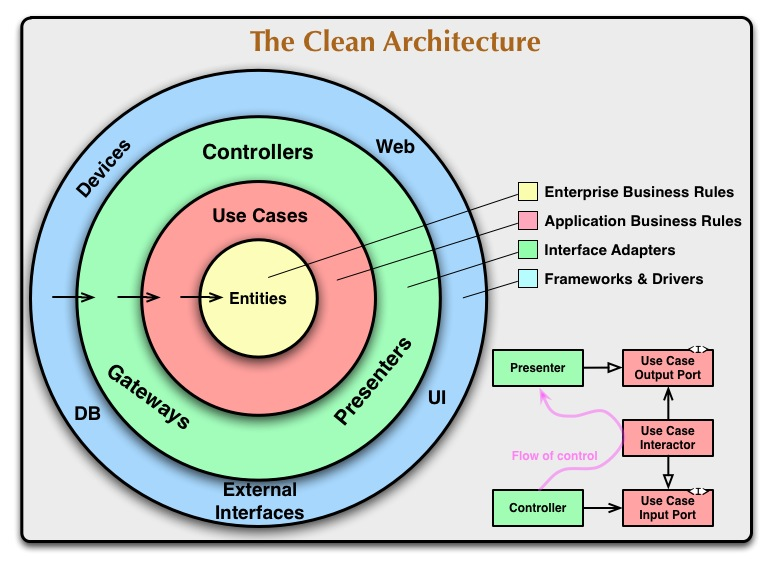

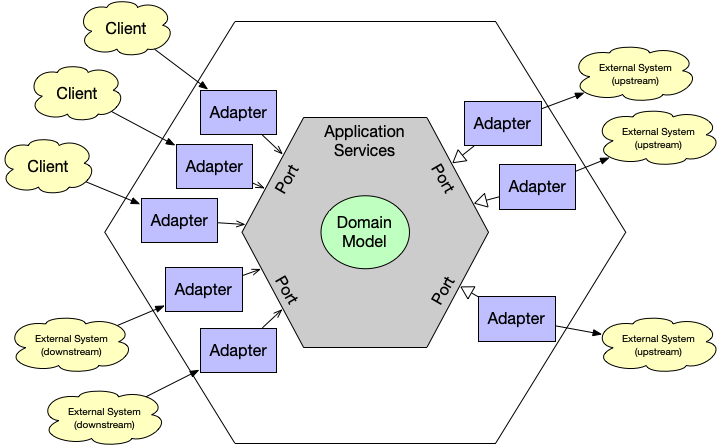

### Что такое Чистая архитектура

Чистая архитектура (англ. Clean Architecture) — это набор принципов и рекомендаций по проектированию программного обеспечения, направленный на создание модульного и гибкого кода, который легко поддерживать и расширять.

#### Какие задачи решаются с помощью Clean Architecture

1. Управление сложностью
- Логика не расползается по всему проекту. Каждая часть кода проекта находится на своем месте.

3. Снижение связности проекта

- Меняется база данных — домен не меняется.
- Меняется HTTP-фреймворк — домен не меняется.
- Меняется DevOps, формат сообщений, UI — домен не меняется.

5. Предсказуемость и тестируемость
- Доменные сервисы без зависимостей легко тестировать.
- Инфраструктуру можно мокать гораздо легче.

### Entitites
Сущности определяются бизнес-правилами предметной области. Сущность может быть объектом с методами или она может представлять собой набор структур данных и функций. Не имеет значения как долго сущность может быть использована в разных приложениях.

### Use Cases
В этом слое реализуется специфика бизнес-правил. Он инкапсулирует и реализует все случаи использования системы. Эти сценарии управляют потоком данных в и из слоя Cущностей для реализации бизнес-правил.

### Interface Adapters
Программное обеспечение в этом слое представляет собой набор адаптеров, которые преобразуют данные из формата наиболее удобным для Сценариев и Сущностей, в формат наиболее удобный для дальнейшего использования, например в БД

### Frameworks and Drivers
Наружный слой обычно состоит из фреймворков, БД, UI и т.д. Как правило, в этом слое не пишется много кода, за исключением кода, который общается с внутренними кругами.

Это слой скопления деталей. Интернет — деталь, БД — деталь, мы держим эти штуки снаружи для уменьшения их влияния

### Порты (Ports)

Порт — это интерфейс (абстракция), определённый ВНУТРИ системы, который описывает, что бизнесу нужно от внешнего мира.

#### Виды портов
##### Входные порты (Input Ports)
- Интерфейсы / контракты use cases.

Кто реализует:
- Application layer.

Кто вызывает:
- Контроллеры (HTTP, CLI, consumers).

```python
class CreateReservationUseCase(Protocol):
    def execute(self, command: CreateReservation) -> ReservationResult: ...
```

##### Выходные порты (Output Ports)
- Интерфейсы, через которые use case общается с внешним миром.

Примеры:
- Repository
- Unit of Work
- Message publisher
- Email sender

```python
class ReservationRepository(Protocol):
    def add(self, reservation: Reservation) -> None: ...
```

#### Адаптеры (Adapters)

Адаптер — это реализация порта, которая связывает бизнес с конкретной технологией.

#### Типы адаптеров
##### Входные адаптеры

Преобразуют внешний запрос в команду use case.

Примеры:
- HTTP controller (FastAPI)
- CLI
- Consumer очереди

```python
@app.post("/reservations")
def create_reservation(request: Request):
    cmd = CreateReservation(...)
    result = create_reservation_uc.execute(cmd)
    return presenter.present(result)
```

##### Выходные адаптеры

Реализуют взаимодействие с внешними системами.

Примеры:
- SQLAlchemyRepository
- KafkaPublisher
- SMTPEmailSender

```python
class SqlAlchemyReservationRepository(ReservationRepository):
    def add(self, reservation):
        ...
```

#### Контроллеры (Controllers)

Контроллер — это входной адаптер, который

- принимает запрос (HTTP/CLI/Message)
- валидирует ввод
- маппит данные в команду
- вызывает use case
  
Контроллер __НЕ содержит__ бизнес-логики.

### Правила
- Правило пересечения границ - границы слоев пересекают только данные (DTO);
- Правило приоритета внутреннего слоя — именно внутренний слой определяет интерфейс, через который он будет взаимодействовать с окружающим миром;
- Правило зависимостей — зависимости должны быть направлены от внутреннего слоя к внешнему.

### Когда Clean Architecture оправдана
- Домен не «плоский»
    - много бизнес-правил, статусов, исключений, инвариантов
    - логика не сводится к CRUD таблица ↔ форма ↔ API

Пример: бронирования + посадка + кухня + биллинг.

- Система будет жить долго и меняться
    - продукт развивается кварталами/годами
    - меняются процессы, интеграции, требования
    - нужно удерживать сложность и не бояться рефакторинга

- Высокая цена изменений/ошибок
    - финансы, юридически значимые операции, SLA, репутационные риски
    - критично воспроизводимое поведение (тестируемость)

- Есть несколько внешних интерфейсов
- API + админка + задачи/воркеры + интеграции + события
- Clean Architecture помогает не дублировать бизнес-логику в каждом входе.

- Планируются смены технологий

    - ORM/БД может поменяться
    - веб-фреймворк может поменяться

    - появится очередь/события/микросервисы
    - CA даёт портативный домен.

- Команда/проект не маленькие
    - несколько разработчиков
    - нужна стабильная архитектурная дисциплина

### Когда Clean Architecture не нужна (или вредна)

Чистый CRUD без смысла:
- таблички + простые фильтры
- логики почти нет
    
Тут CA часто превращается в "100 файлов ради 5 запросов".

Маленький одноразовый проект / MVP на выброс:
- быстро проверить гипотезу
- не будет долгой поддержки

Микросервис-обёртка над чужим API:
- прокси/шлюз/адаптер
- минимум правил

Если нет соглашений, ревью, тестов — получится "псевдослои" и хаос:
- домен зависит от ORM
- use cases вызывают внешние методы (UI\HTTP\...)
- везде dataclasses как DTO

Вы переусложнили, если:
- в домене почти нет поведения, только анемичные классы и геттеры
- use cases — тонкая прослойка, которая просто прокидывает данные в ORM
- репозитории на каждый чих без смысла (UserRepository.save как единственная операция)
- добавили UoW/Bus/Factories, но нет событий, инвариантов, сложных сценариев
- __разработка стала медленнее, а гибкость не выросла__

## References

- https://github.com/pgorecki/python-ddd
- https://github.com/cdddg/py-clean-arch